In [1]:
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
import numpy as np
import pandas as pd

from popt.config import nikhils_extra_etfs, bond, sect, intn, metl

In [2]:
D0 = "2005-01-03"
D1 = "2024-12-31"

rd = pd.read_parquet("../data/return/return_d.parquet").loc[D0:D1]
rf = pd.read_parquet("../data/return/ffr_d.parquet").reindex(rd.index)
rd.shape, rf.shape

((5033, 87), (5033, 1))

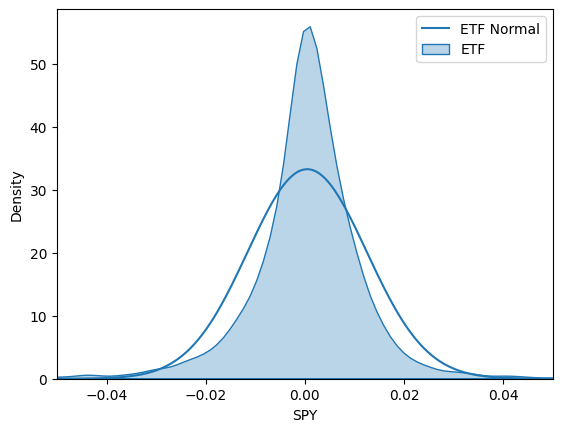

(np.float64(0.0004605070828353925), np.float64(0.011989823163204452))

In [3]:
D0_ = "2005-01-03"
D1_ = "2010-01-03"
D2_ = "2015-01-03"
D3_ = "2020-01-03"
D4_ = "2025-01-03"

etf = rd["SPY"].loc[D0_:D4_]
mu = etf.mean()
sigma = etf.std()

norm_pdf = lambda x: 1/np.sqrt(2*np.pi*sigma**2) * np.exp(-0.5 * (x - mu)**2 / sigma**2)
x = np.linspace(etf.min(), etf.max(), 1000)

plt.plot(x, norm_pdf(x), label="ETF Normal")
sns.kdeplot(etf, label="ETF", fill=True, alpha=0.3)
plt.xlim(-0.05, 0.05)
plt.legend()
plt.show()
mu, sigma

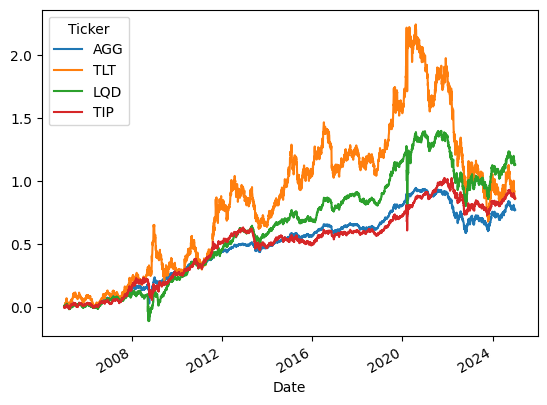

In [4]:
subset = rd[[
    # "SPY",
    # "XLK", "XLV", "XLF", "XLY", "XLI", "XLP", "XLE", "XLU", "XLB",
    # "IYR", "IBB",
    # "GLD", "SLV", "CPER", "PPLT",
    # *metl,
    *bond,
    # "CMBS", "HYXU", "TLTW", "GOVT", "FALN", "EMHY", "LEMB", "SHYG", # "GOVZ", "ICVT",
]].loc[D0_:D4_]
r_cumu = (subset+1.0).cumprod()-1.0
r_cumu.plot(legend=True)
plt.show()

In [8]:
def sharpe_geom(rd: pd.DataFrame, rf: pd.Series):
    assert rd.shape[0] == rf.shape[0]
    num_days = rd.notna().sum(axis=0)
    rd_ = rd.fillna(0.0)
    rf_ = rf.fillna(0.0).values
    ret_ann = ((rd_+1.0).prod() / (rf_+1.0).prod()) ** (252 / num_days) - 1.0
    vol_ann = rd_.std() * np.sqrt(252)
    return ret_ann / vol_ann

def annual_return(rd: pd.DataFrame) -> pd.Series:
    num_days = rd.notna().sum(axis=0)
    return (1.0+rd).prod() ** (252 / num_days)-1.0

def annual_volatility(rd: pd.DataFrame) -> pd.Series:
    return rd.std() * np.sqrt(252)

def total_return(rd: pd.DataFrame) -> pd.Series:
    return (1.0+rd).prod()-1.0


stats = pd.DataFrame({
    "sharpe": sharpe_geom(rd, rf),
    "ret ann": annual_return(rd),
    "vol ann": annual_volatility(rd),
    "ret tot": total_return(rd),
}, index=rd.columns)



(
    stats
    # .reindex(nikhils_extra_etfs + bond)
    .reindex([
        # *sect,
        *bond,
        # *intn,
        # *metl,
        # "AGG", "TLT", "LQD", "TIP", "CMBS", "HYXU", "TLTW", "GOVT", "FALN", "EMHY", "LEMB", "ICVT", "SHYG", "GOVZ",
        ])
    .dropna()
    .sort_values(by="sharpe", ascending=False)
    .head(60)
)

,sharpe,ret ann,vol ann,ret tot
Ticker,,,,
LQD,0.250231,0.038602,0.086215,1.130712
TIP,0.235027,0.031671,0.062787,0.864013
AGG,0.230932,0.029037,0.052680,0.771220
TLT,0.098885,0.031547,0.147992,0.859528


In [7]:
rd[[
    "SPY",
    *bond,
    # "CMBS", "HYXU", "TLTW", "GOVT", "FALN", "EMHY", "LEMB", "ICVT", "SHYG", "GOVZ",
]].corr()

Ticker,SPY,AGG,TLT,LQD,TIP
Ticker,,,,,
SPY,1.000000,-0.010335,-0.323822,0.187871,-0.110603
AGG,-0.010335,1.000000,0.703578,0.700791,0.674271
TLT,-0.323822,0.703578,1.000000,0.539520,0.701494
LQD,0.187871,0.700791,0.539520,1.000000,0.531998
TIP,-0.110603,0.674271,0.701494,0.531998,1.000000
